In [1]:
# Data manipulation
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
# Time series specific
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

In [4]:
# Preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [5]:
# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Utilities
import datetime
import pickle
import os

In [8]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

In [12]:
file_path = r'C:\Users\harid\Downloads\practicum-2\btc_1min_60days.csv'

# Load the dataset
try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully from {file_path}")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the path.")

Dataset loaded successfully from C:\Users\harid\Downloads\practicum-2\btc_1min_60days.csv


In [13]:
df.shape

(86401, 6)

In [14]:
df.head()

,Open time,Open,High,Low,Close,Volume
0,2026-01-30 18:01:00,82987.33,83030.25,82948.00,83030.24,5.18532
1,2026-01-30 18:02:00,83030.25,83199.99,83030.24,83156.34,31.14535
2,2026-01-30 18:03:00,83156.35,83199.99,83117.32,83120.19,5.00500
3,2026-01-30 18:04:00,83120.20,83162.00,83117.32,83148.45,5.32666
4,2026-01-30 18:05:00,83148.45,83236.70,83148.45,83195.61,14.00155


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86401 entries, 0 to 86400
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open time  86401 non-null  object 
 1   Open       86401 non-null  float64
 2   High       86401 non-null  float64
 3   Low        86401 non-null  float64
 4   Close      86401 non-null  float64
 5   Volume     86401 non-null  float64
dtypes: float64(5), object(1)
memory usage: 4.0+ MB


In [16]:
df.dtypes

Open time     object
Open         float64
High         float64
Low          float64
Close        float64
Volume       float64
dtype: object

In [17]:
df.describe()

,Open,High,Low,Close,Volume
count,86401.000000,86401.000000,86401.000000,86401.000000,86401.000000
mean,69637.802426,69670.260391,69605.791752,69637.621489,18.376050
std,3577.250550,3579.662382,3574.968558,3576.967842,35.844088
min,60076.810000,60550.000000,60000.000000,60081.740000,0.140320
25%,67308.880000,67337.210000,67281.960000,67308.870000,4.363500
50%,68936.990000,68964.920000,68909.040000,68936.980000,8.810170
75%,70868.660000,70899.320000,70841.770000,70868.650000,18.900800
max,84560.000000,84621.160000,84489.500000,84559.990000,1575.460240


In [18]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Open time    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64


In [19]:
# Handle missing values (forward fill for time series)
df.fillna(method='ffill', inplace=True)
print("\nMissing values after forward fill:")
print(df.isnull().sum())


Missing values after forward fill:
Open time    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64


In [20]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")


Number of duplicate rows: 0


In [21]:
# Convert 'Open time' to datetime and set as index
df['Open time'] = pd.to_datetime(df['Open time'])
df.set_index('Open time', inplace=True)

In [22]:
# Sort index (important for time series)
df.sort_index(inplace=True)

In [23]:
df.head()

,Open,High,Low,Close,Volume
Open time,,,,,
2026-01-30 18:01:00,82987.33,83030.25,82948.00,83030.24,5.18532
2026-01-30 18:02:00,83030.25,83199.99,83030.24,83156.34,31.14535
2026-01-30 18:03:00,83156.35,83199.99,83117.32,83120.19,5.00500
2026-01-30 18:04:00,83120.20,83162.00,83117.32,83148.45,5.32666
2026-01-30 18:05:00,83148.45,83236.70,83148.45,83195.61,14.00155


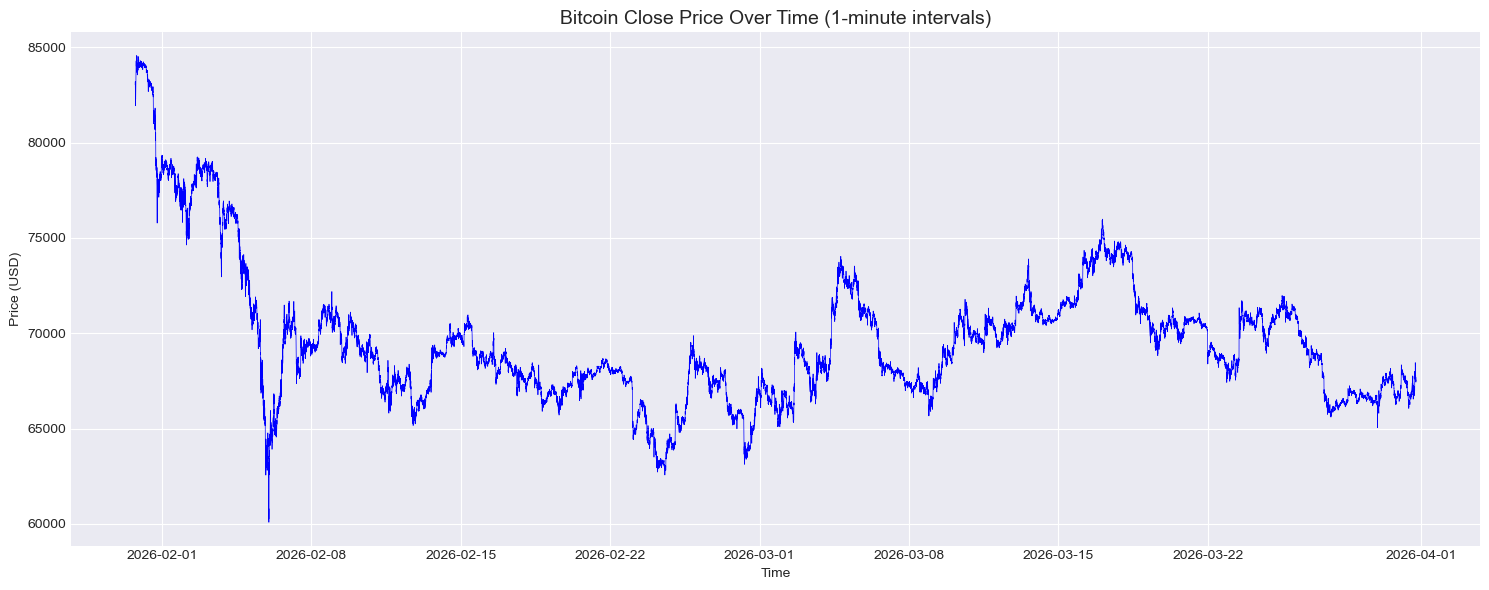

In [24]:
# Time series plot of Close price
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Close'], color='blue', linewidth=0.5)
plt.title('Bitcoin Close Price Over Time (1-minute intervals)', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.savefig('ts_close_price.png', dpi=100)
plt.show()

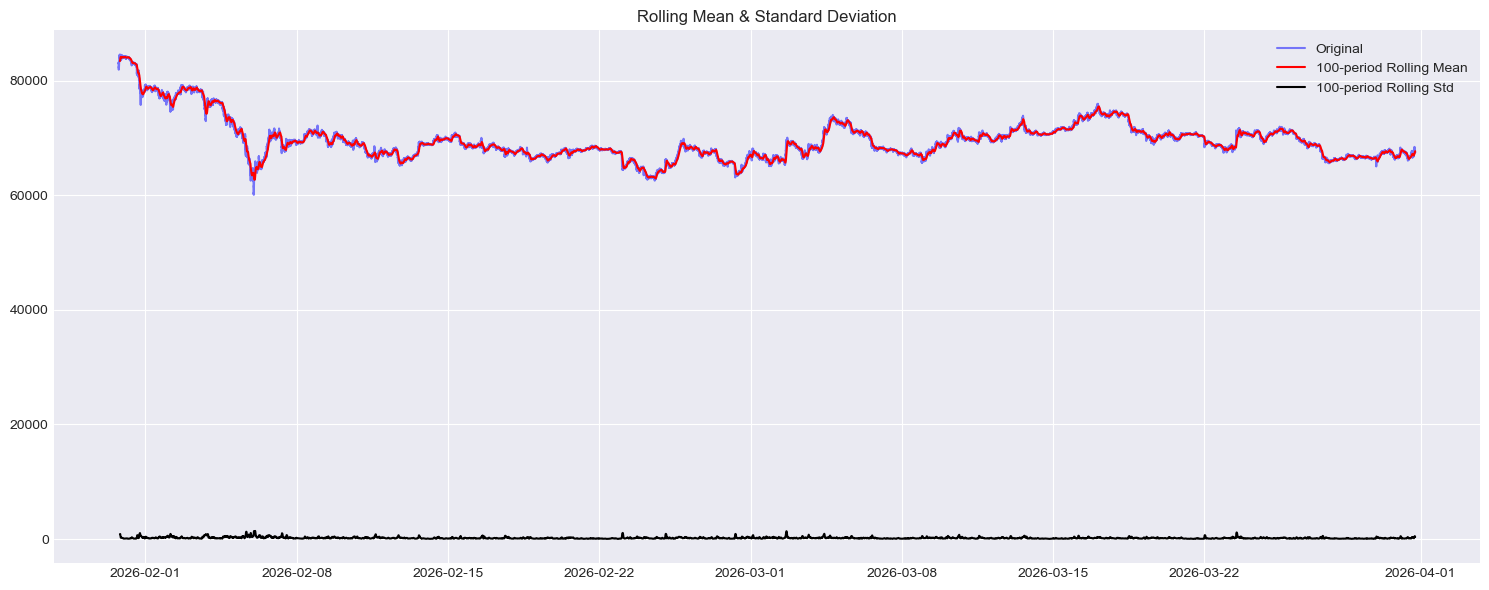

In [25]:
# Rolling statistics
rolling_mean = df['Close'].rolling(window=100).mean()
rolling_std = df['Close'].rolling(window=100).std()

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Close'], color='blue', label='Original', alpha=0.5)
plt.plot(df.index, rolling_mean, color='red', label='100-period Rolling Mean')
plt.plot(df.index, rolling_std, color='black', label='100-period Rolling Std')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('rolling_stats.png', dpi=100)
plt.show()

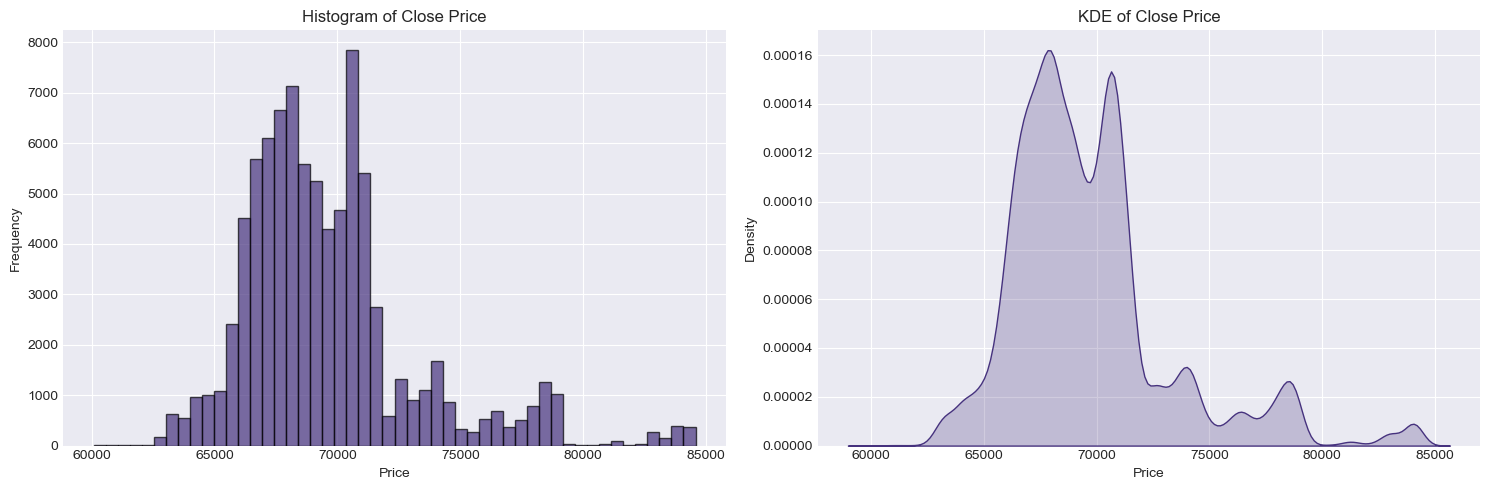

In [26]:
# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['Close'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Histogram of Close Price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# KDE Plot
sns.kdeplot(df['Close'], ax=axes[1], fill=True)
axes[1].set_title('KDE of Close Price')
axes[1].set_xlabel('Price')
plt.tight_layout()
plt.savefig('distribution.png', dpi=100)
plt.show()

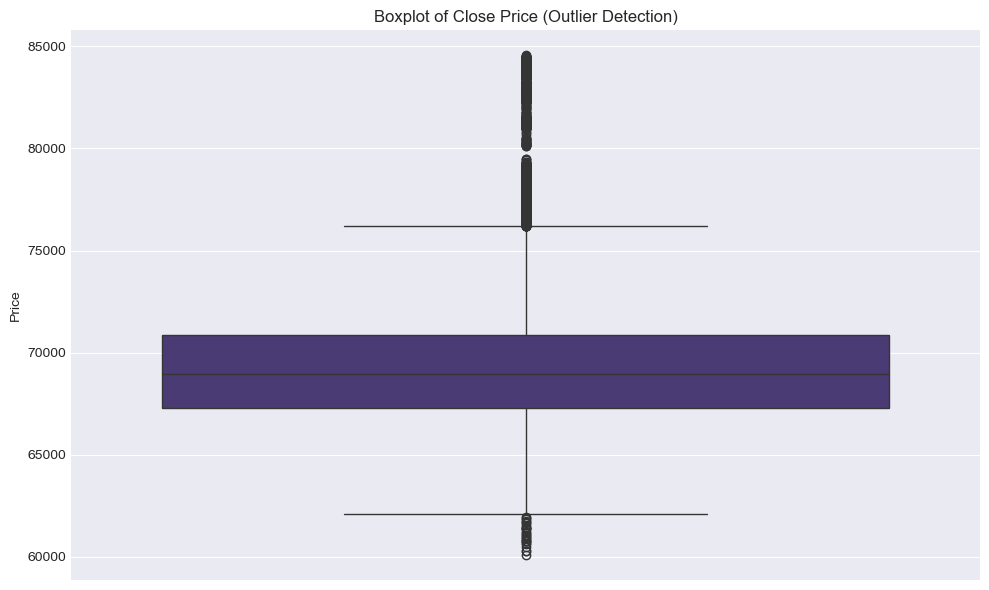

In [27]:
# Boxplot for outlier detection
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Close'])
plt.title('Boxplot of Close Price (Outlier Detection)')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('boxplot.png', dpi=100)
plt.show()

In [28]:
# Outlier detection using IQR
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]
print(f"\nNumber of outliers detected in Close price: {len(outliers)}")
print(f"Outlier range: [{lower_bound:.2f}, {upper_bound:.2f}]")


Number of outliers detected in Close price: 6121
Outlier range: [61969.20, 76208.32]


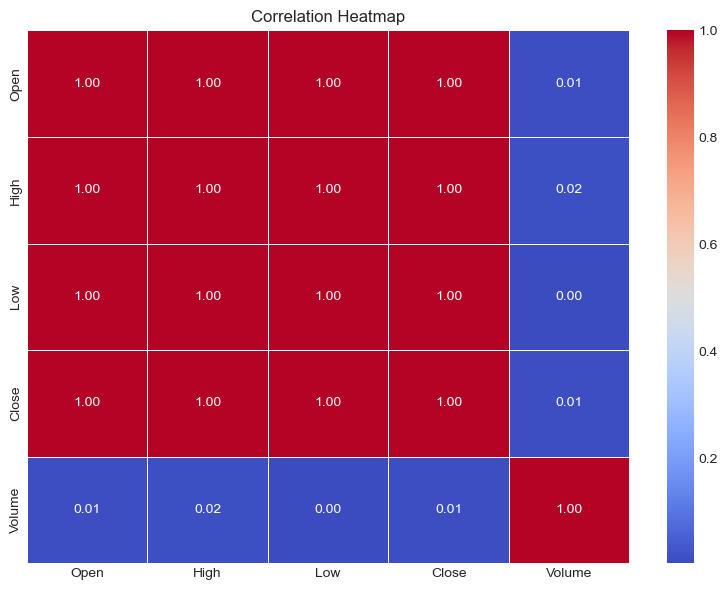

In [29]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()


In [30]:
# Feature Engineering: Add lag features and rolling statistics
df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag2'] = df['Close'].shift(2)
df['Close_MA10'] = df['Close'].rolling(window=10).mean()
df['Close_MA50'] = df['Close'].rolling(window=50).mean()
df['Volume_MA10'] = df['Volume'].rolling(window=10).mean()

In [31]:
df.head()

,Open,High,Low,Close,Volume,Close_lag1,Close_lag2,Close_MA10,Close_MA50,Volume_MA10
Open time,,,,,,,,,,
2026-01-30 18:01:00,82987.33,83030.25,82948.00,83030.24,5.18532,NaN,NaN,NaN,NaN,NaN
2026-01-30 18:02:00,83030.25,83199.99,83030.24,83156.34,31.14535,83030.24,NaN,NaN,NaN,NaN
2026-01-30 18:03:00,83156.35,83199.99,83117.32,83120.19,5.00500,83156.34,83030.24,NaN,NaN,NaN
2026-01-30 18:04:00,83120.20,83162.00,83117.32,83148.45,5.32666,83120.19,83156.34,NaN,NaN,NaN
2026-01-30 18:05:00,83148.45,83236.70,83148.45,83195.61,14.00155,83148.45,83120.19,NaN,NaN,NaN


In [32]:
# Drop NaN values created by lag/rolling features
df.dropna(inplace=True)
print(f"\nData shape after adding features: {df.shape}")


Data shape after adding features: (86352, 10)


In [33]:
# Stationarity Check: ADF Test on Close price
def adf_test(series, title=''):
    """
    Augmented Dickey-Fuller test for stationarity.
    """
    print(f'--- ADF Test for {title} ---')
    result = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print("=> Series is stationary (reject H0).")
    else:
        print("=> Series is non-stationary (fail to reject H0).")
    return result[1]

adf_test(df['Close'], 'Close Price')

--- ADF Test for Close Price ---
ADF Statistic: -4.1582
p-value: 0.0008
Critical Values:
	1%: -3.4304
	5%: -2.8616
	10%: -2.5668
=> Series is stationary (reject H0).


np.float64(0.0007748630833680221)

--- ADF Test for Differenced Close Price ---
ADF Statistic: -38.0847
p-value: 0.0000
Critical Values:
	1%: -3.4304
	5%: -2.8616
	10%: -2.5668
=> Series is stationary (reject H0).


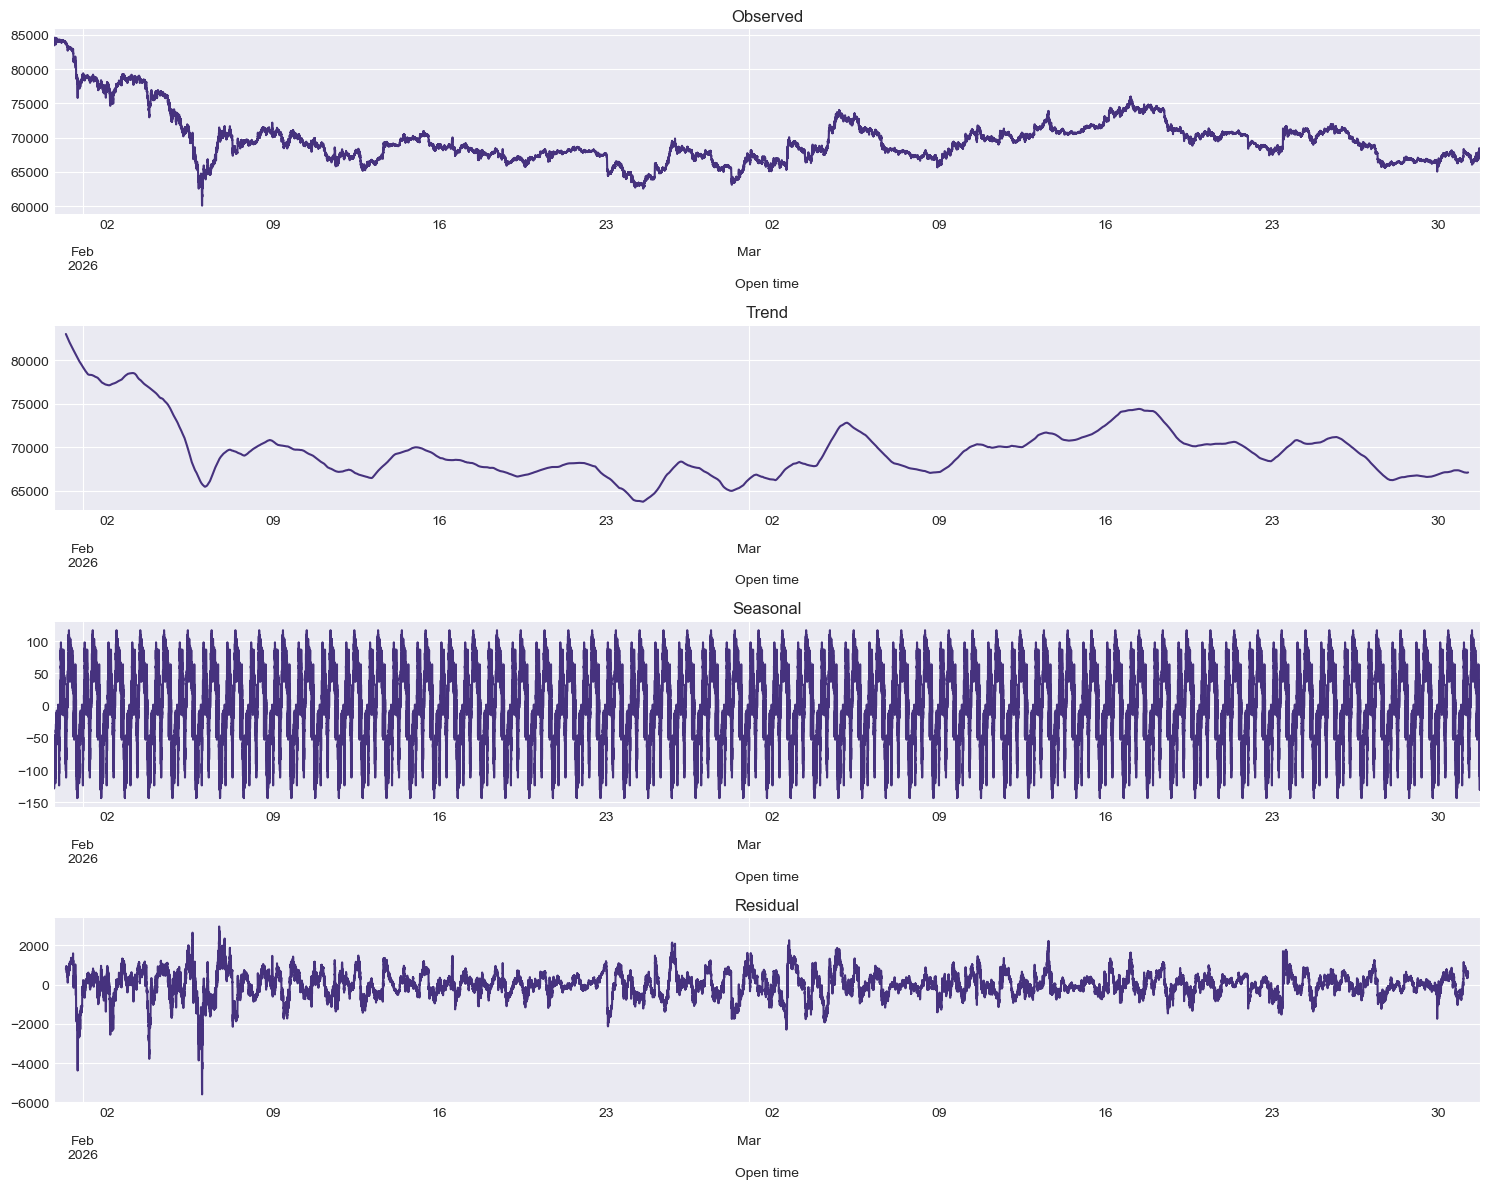

In [34]:
# Differencing if required (we'll do it for ARIMA, but store diff series)
df['Close_diff'] = df['Close'].diff().dropna()
adf_test(df['Close_diff'].dropna(), 'Differenced Close Price')

# 4.10 Seasonal Decomposition
decomposition = seasonal_decompose(df['Close'], model='additive', period=1440)  # 1440 minutes in a day
fig, axes = plt.subplots(4, 1, figsize=(15, 12))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.savefig('seasonal_decomposition.png', dpi=100)
plt.show()

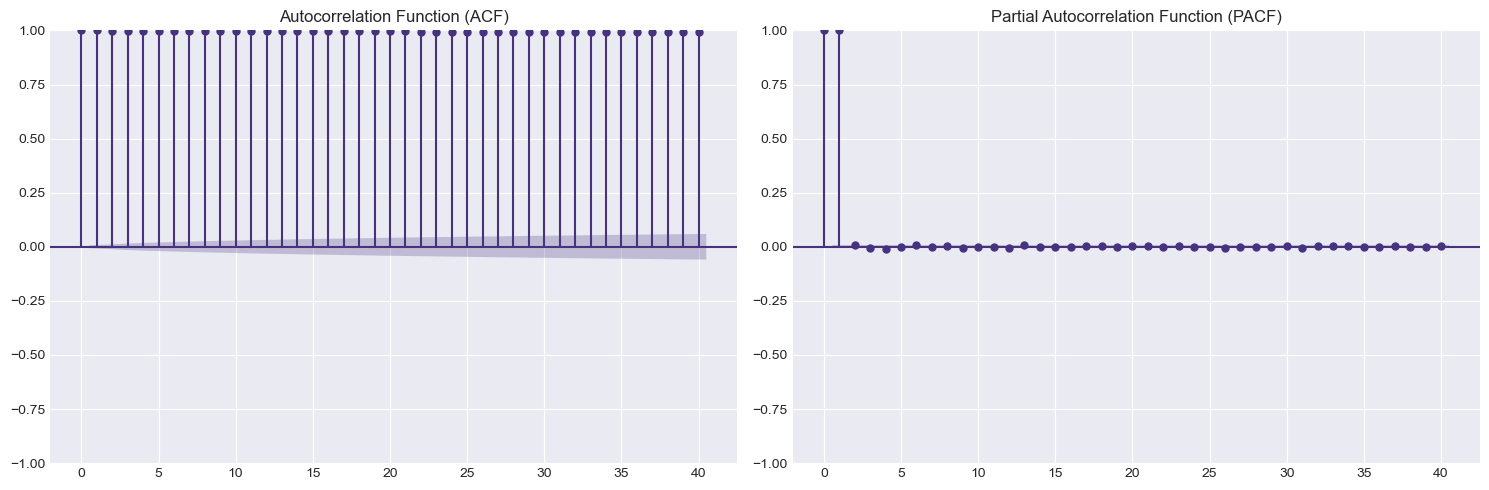

In [35]:
# ACF and PACF plots for ARIMA order selection
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df['Close'].dropna(), lags=40, ax=axes[0], title='Autocorrelation Function (ACF)')
plot_pacf(df['Close'].dropna(), lags=40, ax=axes[1], title='Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=100)
plt.show()

In [36]:
# ## Train-Test Split (Time-based)
# Use Close price for forecasting
ts_data = df['Close'].copy()
# Split into train and test (80% train, 20% test)
train_size = int(len(ts_data) * 0.8)
train, test = ts_data[:train_size], ts_data[train_size:]

print(f"Train set size: {len(train)} ({len(train)/len(ts_data)*100:.1f}%)")
print(f"Test set size: {len(test)} ({len(test)/len(ts_data)*100:.1f}%)")

Train set size: 69081 (80.0%)
Test set size: 17271 (20.0%)


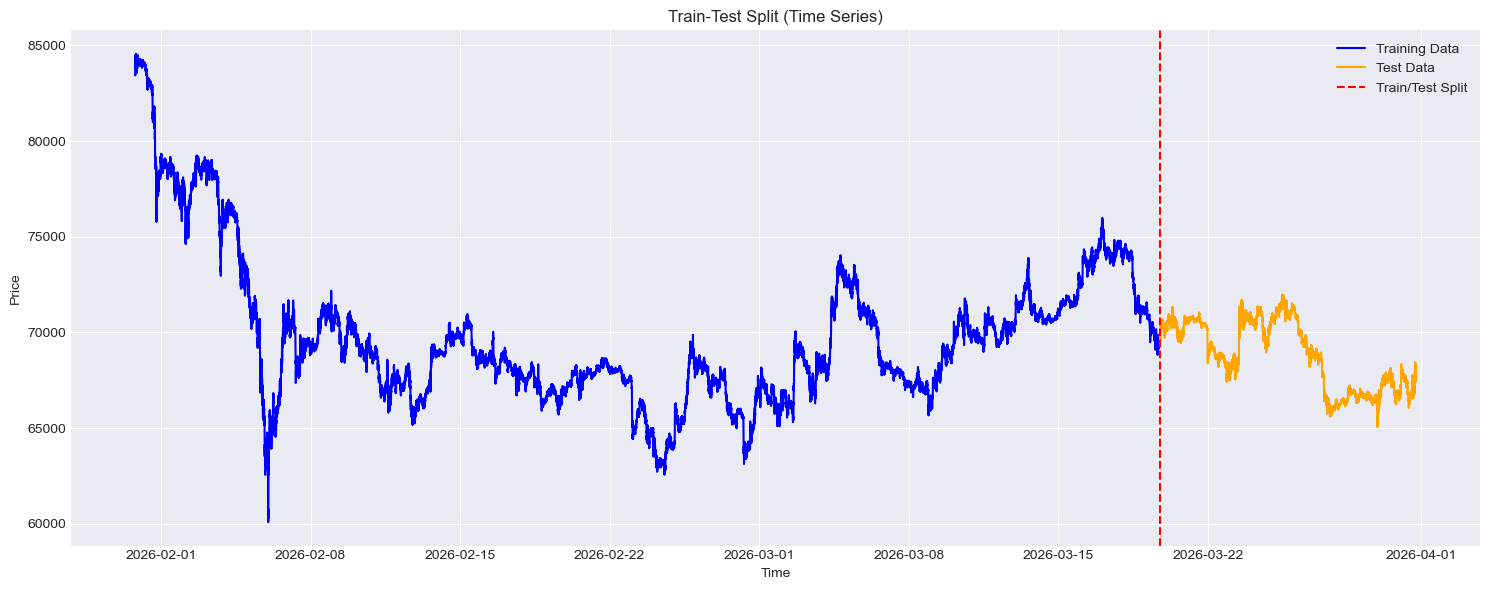

In [37]:
# Visualize the split
plt.figure(figsize=(15, 6))
plt.plot(train.index, train, color='blue', label='Training Data')
plt.plot(test.index, test, color='orange', label='Test Data')
plt.axvline(x=train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Train-Test Split (Time Series)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=100)
plt.show()

In [42]:
# ## ARIMA Model
# Determine ARIMA order (p,d,q)
# We already know d=1 is needed from ADF test. Use ACF/PACF to estimate p and q.
# For demonstration, we'll use a grid search for the best parameters on the training set.

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [39]:
train = train.astype(float)
test = test.astype(float)

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reduce dataset size (important for ARIMA)
ts_data = df['Close'].copy().tail(5000)

train_size = int(len(ts_data) * 0.8)
train, test = ts_data[:train_size], ts_data[train_size:]

train = train.astype(float)
test = test.astype(float)

def evaluate_arima_model(train, test, order):
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=len(test))
        rmse = np.sqrt(mean_squared_error(test, forecast))
        return rmse
    except Exception as e:
        print(f"Error for order {order}: {e}")
        return float('inf')

# Smaller grid (more stable)
p_values = range(0, 3)
d_values = [1]
q_values = range(0, 3)

best_rmse = float('inf')
best_order = None

print("Starting ARIMA tuning...")

for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p, d, q)
            rmse = evaluate_arima_model(train, test, order)
            if rmse < best_rmse:
                best_rmse = rmse
                best_order = order
                print(f"Best order: {order}, RMSE: {rmse:.4f}")

if best_order is None:
    raise ValueError("No valid ARIMA model found.")

print(f"\nFinal Best ARIMA order: {best_order}")

# Train final model
arima_model = ARIMA(train, order=best_order)
arima_fit = arima_model.fit()

print(arima_fit.summary())

Starting ARIMA tuning...
Best order: (0, 1, 0), RMSE: 577.4942

Final Best ARIMA order: (0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 4000
Model:                 ARIMA(0, 1, 0)   Log Likelihood              -20162.633
Date:                Thu, 16 Apr 2026   AIC                          40327.266
Time:                        21:45:04   BIC                          40333.560
Sample:                    03-28-2026   HQIC                         40329.497
                         - 03-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1402.0774      6.644    211.014      0.000    1389.054    1415.100
Ljung-Box (L1) (Q):              

In [41]:
# Fit the final ARIMA model on full training data
print("\nFitting final ARIMA model on training data...")
arima_model = ARIMA(train, order=best_order)
arima_fit = arima_model.fit()
print(arima_fit.summary())


Fitting final ARIMA model on training data...
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 4000
Model:                 ARIMA(0, 1, 0)   Log Likelihood              -20162.633
Date:                Thu, 16 Apr 2026   AIC                          40327.266
Time:                        21:45:54   BIC                          40333.560
Sample:                    03-28-2026   HQIC                         40329.497
                         - 03-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1402.0774      6.644    211.014      0.000    1389.054    1415.100
Ljung-Box (L1) (Q):                  13.87   Jarque-Bera (JB):            302129.85


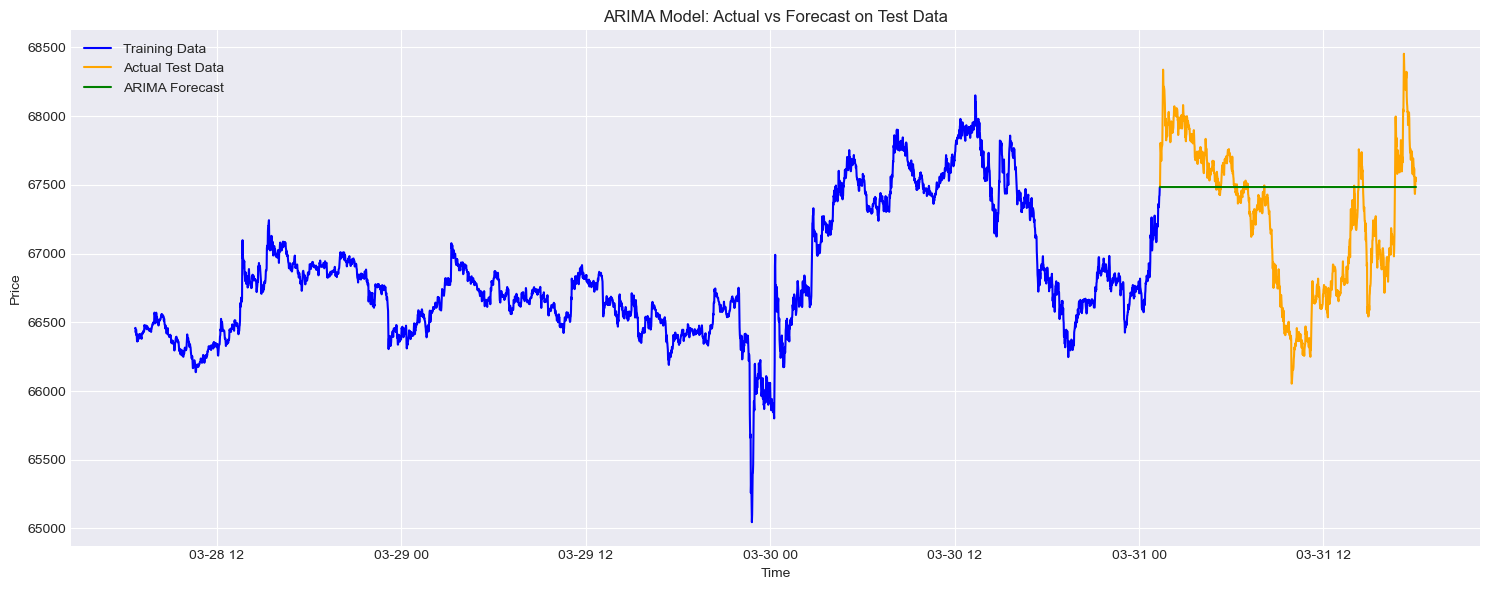

In [42]:
# Forecast on test set
arima_forecast_test = arima_fit.forecast(steps=len(test))
arima_forecast_test_index = test.index

# Plot ARIMA predictions vs actual test data
plt.figure(figsize=(15, 6))
plt.plot(train.index, train, color='blue', label='Training Data')
plt.plot(test.index, test, color='orange', label='Actual Test Data')
plt.plot(arima_forecast_test_index, arima_forecast_test, color='green', label='ARIMA Forecast')
plt.title('ARIMA Model: Actual vs Forecast on Test Data')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('arima_test_forecast.png', dpi=100)
plt.show()

In [43]:
# ## LSTM Model
# Prepare data for LSTM
def create_sequences(data, window_size=60):
    """
    Create sequences of past data to predict the next value.
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [44]:
# Scale the data for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train.values.reshape(-1, 1))
scaled_test = scaler.transform(test.values.reshape(-1, 1))

In [45]:
# Create sequences
window_size = 60
X_train, y_train = create_sequences(scaled_train, window_size)
X_test, y_test = create_sequences(scaled_test, window_size)

In [46]:
# Reshape for LSTM input (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [47]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3940, 60, 1)
y_train shape: (3940, 1)
X_test shape: (940, 60, 1)
y_test shape: (940, 1)


In [48]:
# Build LSTM model
lstm_model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

In [49]:
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Train LSTM with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0281 - val_loss: 9.9031e-04
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0059 - val_loss: 0.0015
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0050 - val_loss: 9.2796e-04
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0044 - val_loss: 8.2954e-04
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0041 - val_loss: 9.2875e-04
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0039 - val_loss: 0.0014
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0036 - val_loss: 9.6252e-04
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0034 - val_loss: 6.3198e-04
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0032 - val_loss: 6.0249e-04
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0031 - val_loss: 0.0012
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0029 - val_loss: 5.0754e-04
Epoch 12/

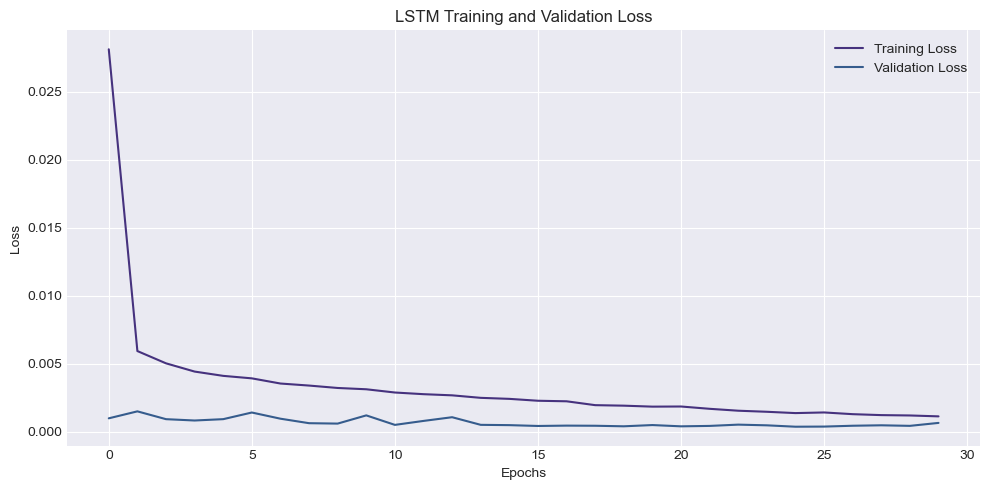

In [51]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('lstm_loss.png', dpi=100)
plt.show()

In [52]:
# LSTM Predictions on test set
lstm_predictions_scaled = lstm_model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [53]:
# Align indices for test set predictions (first window_size values are not predicted)
lstm_predictions_index = test.index[window_size:]

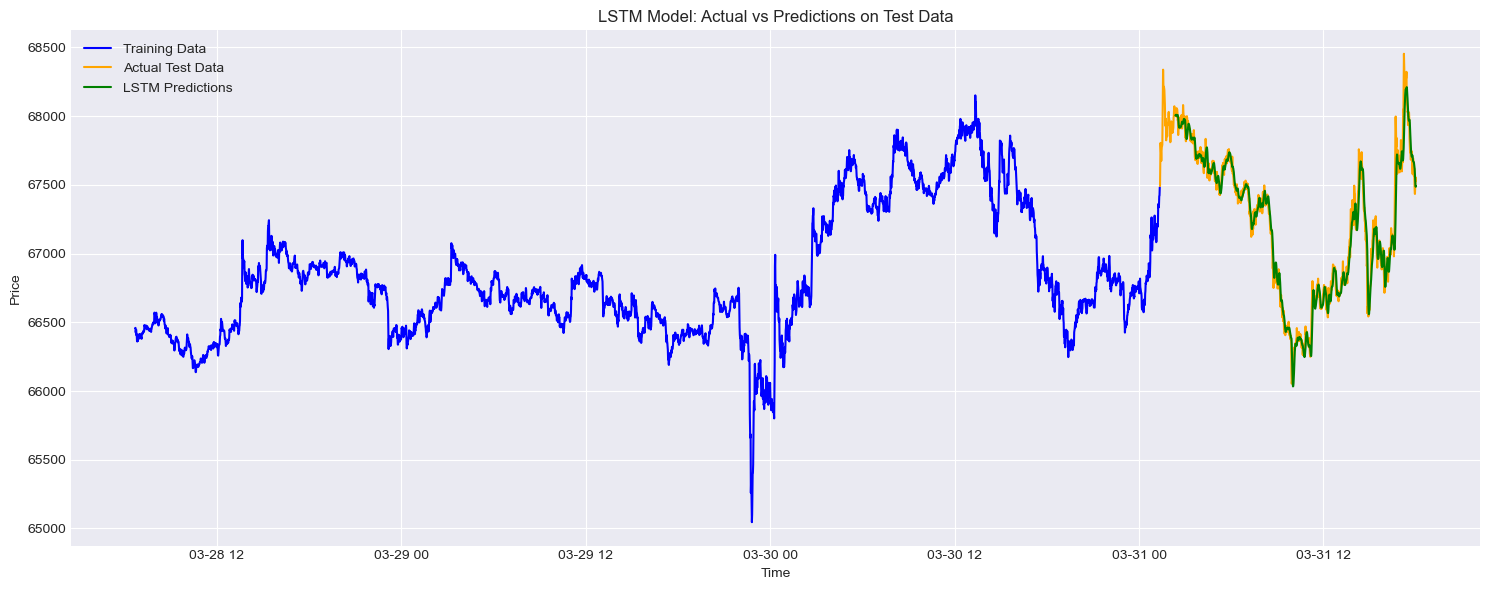

In [54]:
# Plot LSTM predictions vs actual test data
plt.figure(figsize=(15, 6))
plt.plot(train.index, train, color='blue', label='Training Data')
plt.plot(test.index, test, color='orange', label='Actual Test Data')
plt.plot(lstm_predictions_index, lstm_predictions, color='green', label='LSTM Predictions')
plt.title('LSTM Model: Actual vs Predictions on Test Data')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('lstm_test_predictions.png', dpi=100)
plt.show()

In [55]:
# ## Performance Evaluation
# ARIMA Metrics
arima_actual = test.values
arima_pred = arima_forecast_test.values

arima_mae = mean_absolute_error(arima_actual, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(arima_actual, arima_pred))
arima_mape = np.mean(np.abs((arima_actual - arima_pred) / arima_actual)) * 100

In [56]:
# LSTM Metrics (ensure same length as ARIMA predictions)
# ARIMA predicts all test points, LSTM predicts after window_size
common_length = min(len(arima_pred), len(lstm_predictions))
lstm_actual = test.values[-common_length:]  # Last common_length points
lstm_pred = lstm_predictions[-common_length:].flatten()

lstm_mae = mean_absolute_error(lstm_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(lstm_actual, lstm_pred))
lstm_mape = np.mean(np.abs((lstm_actual - lstm_pred) / lstm_actual)) * 100

print("--- Model Performance on Test Set ---")
print(f"ARIMA - MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f}, MAPE: {arima_mape:.2f}%")
print(f"LSTM  - MAE: {lstm_mae:.2f}, RMSE: {lstm_rmse:.2f}, MAPE: {lstm_mape:.2f}%")

--- Model Performance on Test Set ---
ARIMA - MAE: 466.92, RMSE: 577.49, MAPE: 0.70%
LSTM  - MAE: 61.61, RMSE: 94.45, MAPE: 0.09%


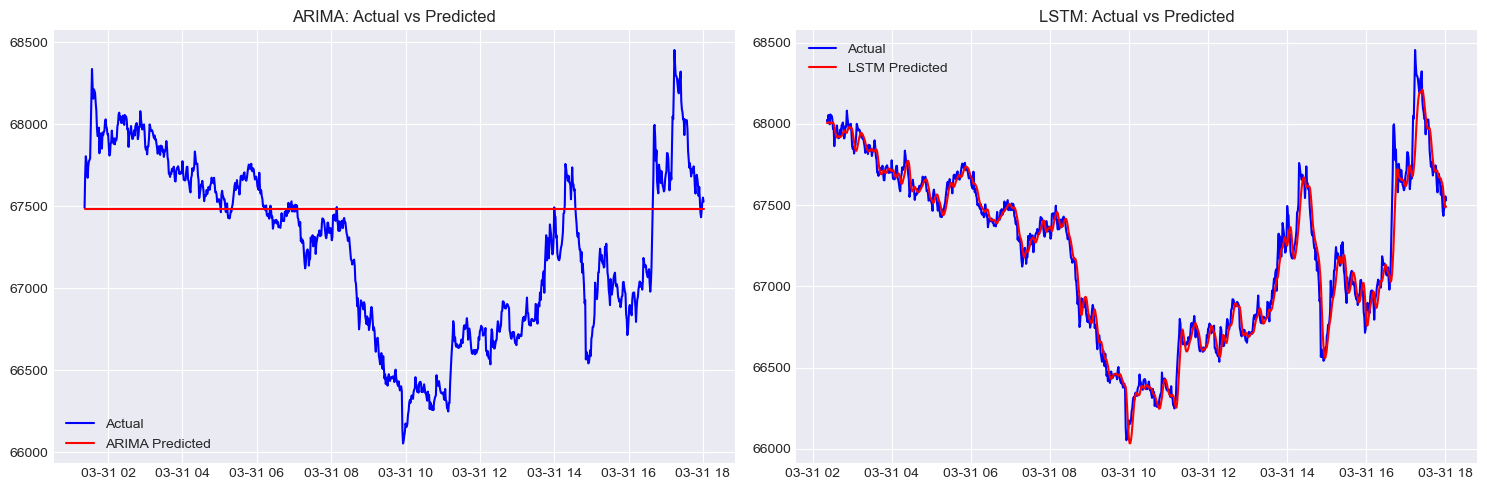

In [57]:
# Actual vs Predicted Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ARIMA
axes[0].plot(test.index, test, label='Actual', color='blue')
axes[0].plot(test.index, arima_forecast_test, label='ARIMA Predicted', color='red')
axes[0].set_title('ARIMA: Actual vs Predicted')
axes[0].legend()
axes[0].grid(True)

# LSTM
axes[1].plot(lstm_predictions_index, lstm_actual[-len(lstm_predictions_index):], label='Actual', color='blue')
axes[1].plot(lstm_predictions_index, lstm_predictions, label='LSTM Predicted', color='red')
axes[1].set_title('LSTM: Actual vs Predicted')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=100)
plt.show()

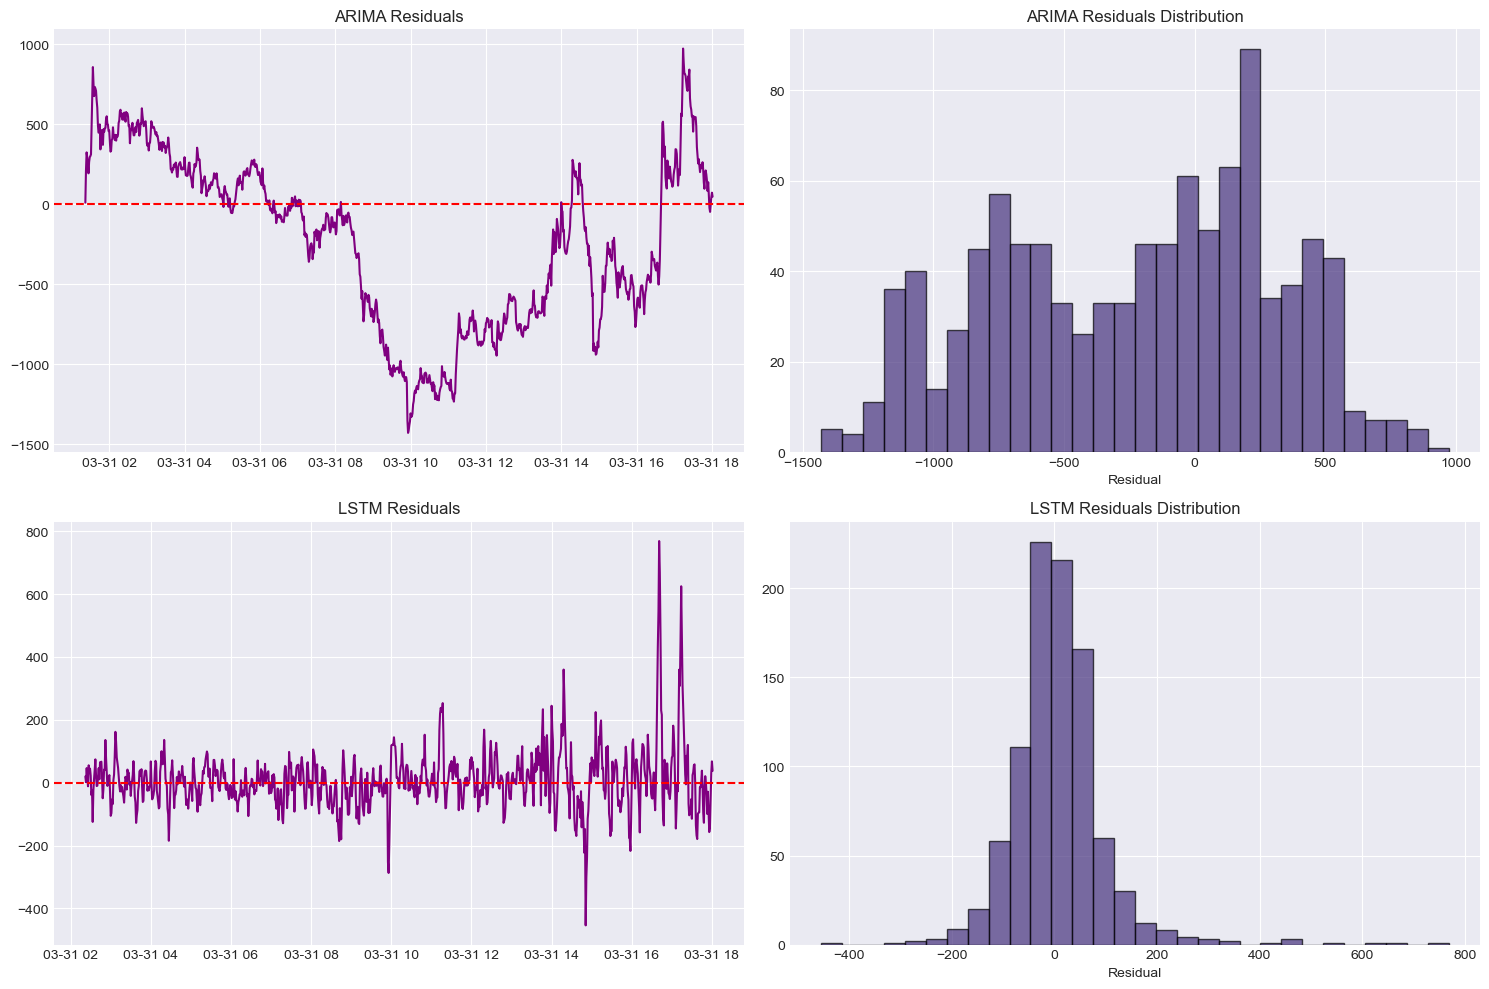

In [58]:
# Residual Analysis
arima_residuals = arima_actual - arima_pred
lstm_residuals = lstm_actual - lstm_pred.flatten()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ARIMA residuals
axes[0,0].plot(test.index, arima_residuals, color='purple')
axes[0,0].axhline(y=0, color='red', linestyle='--')
axes[0,0].set_title('ARIMA Residuals')
axes[0,0].grid(True)

axes[0,1].hist(arima_residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0,1].set_title('ARIMA Residuals Distribution')
axes[0,1].set_xlabel('Residual')

# LSTM residuals
axes[1,0].plot(lstm_predictions_index, lstm_residuals, color='purple')
axes[1,0].axhline(y=0, color='red', linestyle='--')
axes[1,0].set_title('LSTM Residuals')
axes[1,0].grid(True)

axes[1,1].hist(lstm_residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1,1].set_title('LSTM Residuals Distribution')
axes[1,1].set_xlabel('Residual')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=100)
plt.show()

In [59]:
# ## Model Comparison
# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'LSTM'],
    'MAE': [arima_mae, lstm_mae],
    'RMSE': [arima_rmse, lstm_rmse],
    'MAPE (%)': [arima_mape, lstm_mape]
})

print("\n--- Model Comparison ---")
display(comparison)


--- Model Comparison ---


,Model,MAE,RMSE,MAPE (%)
0,ARIMA,466.918000,577.494244,0.697140
1,LSTM,61.613854,94.449703,0.091607


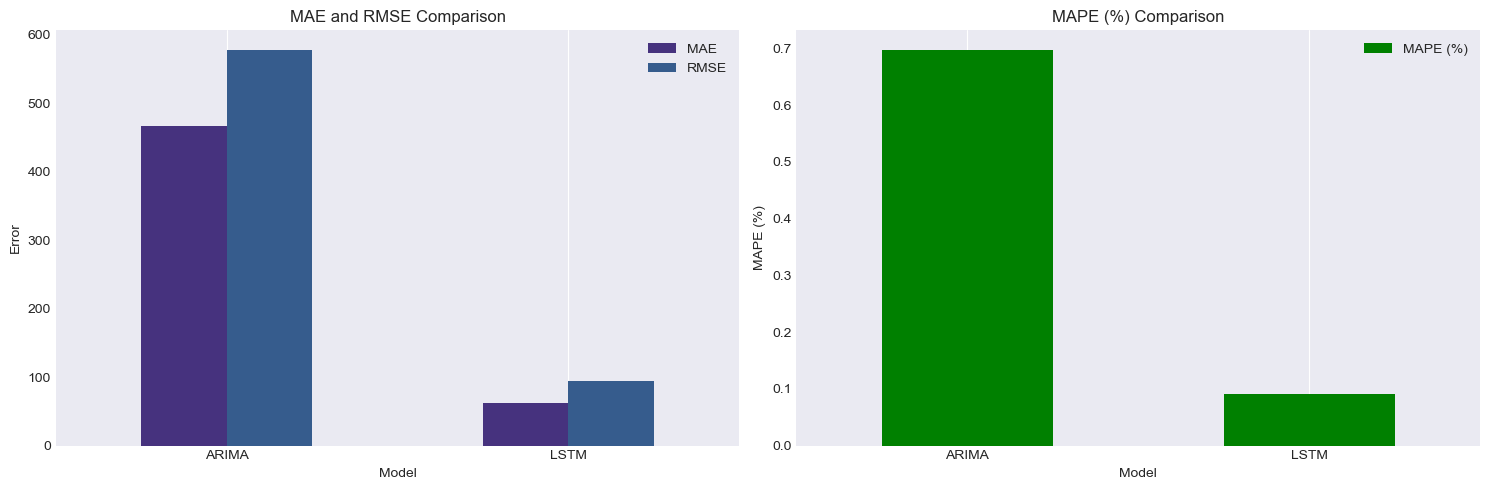

In [60]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MAE and RMSE
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('MAE and RMSE Comparison')
axes[0].set_ylabel('Error')
axes[0].legend()
axes[0].grid(axis='y')

# MAPE
comparison.set_index('Model')[['MAPE (%)']].plot(kind='bar', ax=axes[1], rot=0, color=['green'])
axes[1].set_title('MAPE (%) Comparison')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend()
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()

In [61]:
# ## Future Forecasting (Next N Steps)

# User input for number of future steps
future_steps = 60  # e.g., next 60 minutes
print(f"Forecasting next {future_steps} minutes...")

Forecasting next 60 minutes...


In [62]:
# ARIMA Future Forecast
arima_future_forecast = arima_fit.forecast(steps=future_steps)
arima_future_index = pd.date_range(start=test.index[-1], periods=future_steps+1, freq='1min')[1:]

In [63]:
# LSTM Future Forecast
# Use the last window_size points from the entire dataset to predict the next point
last_sequence = scaled_train[-window_size:] if len(scaled_train) >= window_size else scaled_train
# Ensure last_sequence has shape (window_size, 1)
if last_sequence.shape[0] != window_size:
    # Pad if necessary (should not happen with our data)
    print("Warning: Last sequence length mismatch. Adjusting...")
    # For simplicity, we'll use the last available sequence
    last_sequence = scaled_train[-window_size:]

lstm_future_forecast = []
current_sequence = last_sequence.copy()
for _ in range(future_steps):
    # Reshape for prediction
    current_input = current_sequence.reshape((1, window_size, 1))
    next_pred_scaled = lstm_model.predict(current_input, verbose=0)
    lstm_future_forecast.append(next_pred_scaled[0, 0])
    # Update sequence: drop first element and append prediction
    current_sequence = np.append(current_sequence[1:], next_pred_scaled, axis=0)

# Inverse transform LSTM forecasts
lstm_future_forecast = scaler.inverse_transform(np.array(lstm_future_forecast).reshape(-1, 1)).flatten()
lstm_future_index = arima_future_index  # Same index

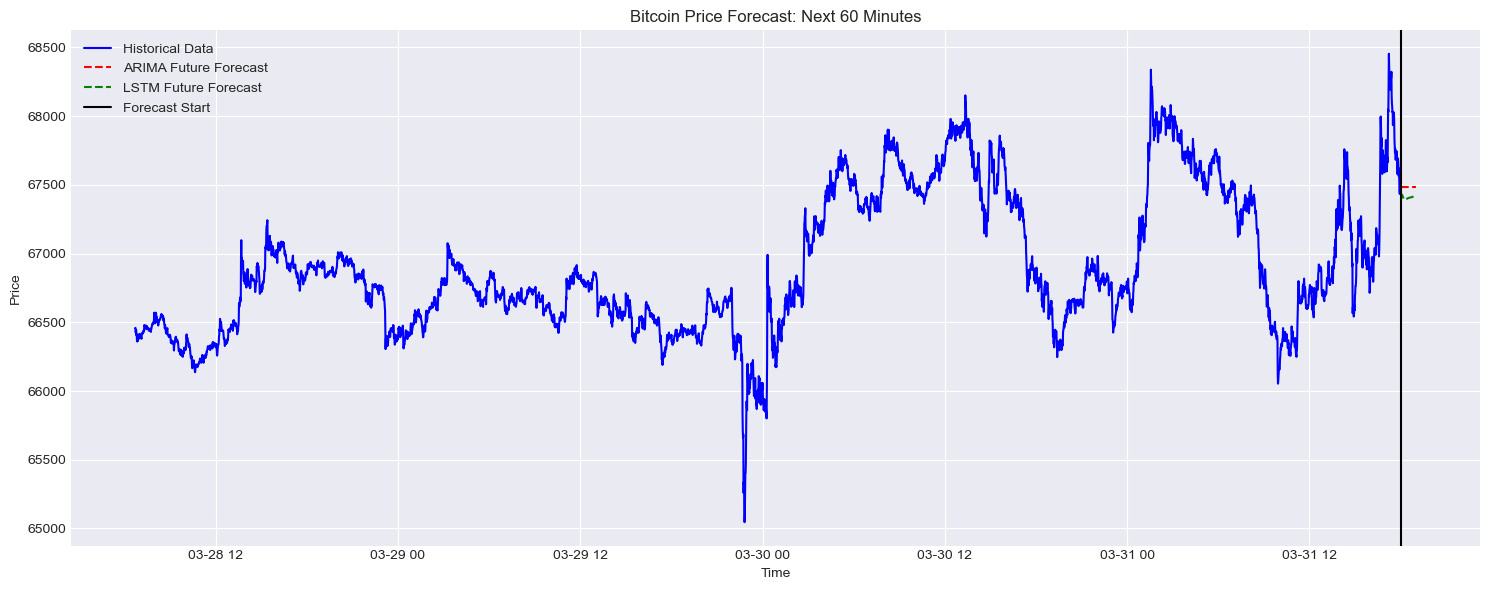

In [64]:
# Plot future forecasts
plt.figure(figsize=(15, 6))
plt.plot(ts_data.index, ts_data, color='blue', label='Historical Data')
plt.plot(arima_future_index, arima_future_forecast, color='red', linestyle='--', label='ARIMA Future Forecast')
plt.plot(lstm_future_index, lstm_future_forecast, color='green', linestyle='--', label='LSTM Future Forecast')
plt.axvline(x=ts_data.index[-1], color='black', linestyle='-', label='Forecast Start')
plt.title(f'Bitcoin Price Forecast: Next {future_steps} Minutes')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=100)
plt.show()

In [65]:
# ## Save Outputs
# Create output directory
output_dir = 'time_series_forecasting_outputs'
os.makedirs(output_dir, exist_ok=True)

# Save forecast results
forecast_df = pd.DataFrame({
    'Timestamp': arima_future_index,
    'ARIMA_Forecast': arima_future_forecast,
    'LSTM_Forecast': lstm_future_forecast
})
forecast_df.to_csv(os.path.join(output_dir, 'future_forecasts.csv'), index=False)
print(f"Future forecasts saved to {output_dir}/future_forecasts.csv")

# Save performance metrics
metrics_df = comparison.copy()
metrics_df.to_csv(os.path.join(output_dir, 'model_performance.csv'), index=False)
print(f"Performance metrics saved to {output_dir}/model_performance.csv")

Future forecasts saved to time_series_forecasting_outputs/future_forecasts.csv
Performance metrics saved to time_series_forecasting_outputs/model_performance.csv


In [71]:
# ## Model Saving & Loading

In [66]:
# Save ARIMA model
arima_model_path = os.path.join(output_dir, 'arima_model.pkl')
with open(arima_model_path, 'wb') as f:
    pickle.dump(arima_fit, f)
print(f"ARIMA model saved to {arima_model_path}")

ARIMA model saved to time_series_forecasting_outputs\arima_model.pkl


In [67]:
# Save LSTM model
lstm_model_path = os.path.join(output_dir, 'lstm_model.h5')
lstm_model.save(lstm_model_path)
print(f"LSTM model saved to {lstm_model_path}")

LSTM model saved to time_series_forecasting_outputs\lstm_model.h5


In [68]:
# Save scaler for LSTM
scaler_path = os.path.join(output_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {scaler_path}")

Scaler saved to time_series_forecasting_outputs\scaler.pkl


In [69]:
# Load and test models
print("\n--- Testing model loading ---")


--- Testing model loading ---


In [70]:
# Load ARIMA
with open(arima_model_path, 'rb') as f:
    loaded_arima = pickle.load(f)
print("ARIMA model loaded successfully.")

ARIMA model loaded successfully.


In [71]:
# Load LSTM
loaded_lstm = tf.keras.models.load_model(lstm_model_path, compile=False)
print("LSTM model loaded successfully.")

LSTM model loaded successfully.


In [72]:
# Load scaler
with open(scaler_path, 'rb') as f:
    loaded_scaler = pickle.load(f)
print("Scaler loaded successfully.")

Scaler loaded successfully.


In [73]:
# Test prediction with loaded models
sample_forecast_arima = loaded_arima.forecast(steps=5)
print(f"Sample ARIMA forecast (next 5 steps): {sample_forecast_arima}")

Sample ARIMA forecast (next 5 steps): 2026-03-31 01:22:00    67482.33
2026-03-31 01:23:00    67482.33
2026-03-31 01:24:00    67482.33
2026-03-31 01:25:00    67482.33
2026-03-31 01:26:00    67482.33
Freq: min, Name: predicted_mean, dtype: float64


In [80]:
# Test LSTM with last sequence
last_seq = scaled_train[-window_size:]
sample_forecast_lstm_scaled = loaded_lstm.predict(last_seq.reshape(1, window_size, 1), verbose=0)
sample_forecast_lstm = loaded_scaler.inverse_transform(sample_forecast_lstm_scaled)
print(f"Sample LSTM forecast (next step): {sample_forecast_lstm[0,0]:.2f}")

Sample LSTM forecast (next step): 67411.70
